# Loss Functions

Cross-Entropy, MSE, Hinge, and Focal Loss — from scratch, validated against PyTorch,
and stress-tested to reveal *why* each one is the right (or wrong) tool for a job.

We answer four concrete questions with numbers, not just formulas:
1. Why does using MSE for classification make learning stall when the model is confidently wrong?
2. Why is MAE robust to outliers in regression while MSE is not?
3. Why does hinge loss produce sparse "support vectors" while cross-entropy keeps pushing every point?
4. Why does focal loss help with class imbalance, and what does it cost you?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. From-Scratch Implementations

### Mean Squared Error (MSE)
$$L_{\text{MSE}} = \frac{1}{n}\sum_i (\hat y_i - y_i)^2 \qquad \frac{\partial L}{\partial \hat y_i} = \frac{2(\hat y_i - y_i)}{n}$$

### Mean Absolute Error (MAE)
$$L_{\text{MAE}} = \frac{1}{n}\sum_i |\hat y_i - y_i| \qquad \frac{\partial L}{\partial \hat y_i} = \frac{\text{sign}(\hat y_i - y_i)}{n}$$

### Binary Cross-Entropy (BCE)
Derived from the Bernoulli negative log-likelihood, $p \in (0,1)$ a probability, $y\in\{0,1\}$:

$$L_{\text{BCE}} = -\frac{1}{n}\sum_i \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big]$$

If $p=\sigma(z)$ (sigmoid), the chain rule gives the famously clean result
$\partial L/\partial z = p - y$ — the sigmoid's own derivative $p(1-p)$ *cancels analytically*
with the $1/p$ and $1/(1-p)$ terms from the log-likelihood.

### Categorical Cross-Entropy (Softmax)
For $K$ classes, one-hot target $y$, softmax probabilities $p_k = e^{z_k}/\sum_j e^{z_j}$:

$$L_{\text{CCE}} = -\frac{1}{n}\sum_i\sum_k y_{ik}\log p_{ik} \qquad \frac{\partial L}{\partial z_k} = \frac{p_k - y_k}{n}$$

Same clean $p - y$ form generalizes from BCE.

### Hinge Loss (SVM)
For labels $y\in\{-1,+1\}$ and raw score $f(x)$:

$$L_{\text{hinge}} = \frac{1}{n}\sum_i \max(0,\, 1 - y_i f(x_i))$$

Zero loss (and zero gradient) once a point is correctly classified with margin $\geq 1$ — this
is what makes SVM solutions **sparse**.

### Focal Loss
Introduced by Lin et al. (2017, RetinaNet) to fix class imbalance in dense object detection:

$$L_{\text{focal}} = -\alpha_t (1-p_t)^\gamma \log(p_t), \qquad p_t = \begin{cases}p & y=1\\ 1-p & y=0\end{cases}$$

The $(1-p_t)^\gamma$ **modulating factor** down-weights already-well-classified examples
($p_t \to 1 \Rightarrow (1-p_t)^\gamma \to 0$), forcing the optimizer to spend its gradient
budget on hard/rare examples. $\alpha_t$ additionally re-weights the rare class. $\gamma=0$
recovers ordinary (weighted) cross-entropy.

In [2]:
def mse_loss(y_pred, y_true): return np.mean((y_pred - y_true) ** 2)
def mse_grad(y_pred, y_true): return 2 * (y_pred - y_true) / y_pred.size

def mae_loss(y_pred, y_true): return np.mean(np.abs(y_pred - y_true))
def mae_grad(y_pred, y_true): return np.sign(y_pred - y_true) / y_pred.size

def bce_loss(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_grad_wrt_p(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return (-(y / p) + (1 - y) / (1 - p)) / p.size

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cce_loss(probs, y_onehot, eps=1e-12):
    probs = np.clip(probs, eps, 1 - eps)
    return -np.mean(np.sum(y_onehot * np.log(probs), axis=1))

def hinge_loss(scores, y_pm):
    return np.mean(np.maximum(0, 1 - y_pm * scores))

def hinge_grad(scores, y_pm):
    margin = 1 - y_pm * scores
    grad = np.where(margin > 0, -y_pm, 0.0)
    return grad / scores.size

def focal_loss(p, y, alpha=0.25, gamma=2.0, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    pt = np.where(y == 1, p, 1 - p)
    alpha_t = np.where(y == 1, alpha, 1 - alpha)
    return np.mean(-alpha_t * (1 - pt) ** gamma * np.log(pt))

print("Loss functions defined: MSE, MAE, BCE, CCE, Hinge, Focal")

Loss functions defined: MSE, MAE, BCE, CCE, Hinge, Focal


## 2. Validation Against PyTorch and Numerical Gradients

Every loss and its gradient must match a trusted reference to machine precision before we trust any conclusion drawn from it.

In [3]:
# ---- MSE ----
y_pred_np = np.random.randn(20)
y_true_np = np.random.randn(20)
y_pred_t = torch.tensor(y_pred_np, requires_grad=True)
y_true_t = torch.tensor(y_true_np)
loss_t = F.mse_loss(y_pred_t, y_true_t)
loss_t.backward()
print(f"MSE   : numpy={mse_loss(y_pred_np, y_true_np):.10f}  torch={loss_t.item():.10f}  "
      f"grad max diff={np.abs(mse_grad(y_pred_np, y_true_np) - y_pred_t.grad.numpy()).max():.2e}")

# ---- MAE ----
y_pred_t2 = torch.tensor(y_pred_np, requires_grad=True)
loss_mae_t = F.l1_loss(y_pred_t2, y_true_t)
loss_mae_t.backward()
print(f"MAE   : numpy={mae_loss(y_pred_np, y_true_np):.10f}  torch={loss_mae_t.item():.10f}  "
      f"grad max diff={np.abs(mae_grad(y_pred_np, y_true_np) - y_pred_t2.grad.numpy()).max():.2e}")

# ---- BCE ----
p_np = np.random.uniform(0.01, 0.99, 20)
y_np = np.random.randint(0, 2, 20).astype(float)
p_t = torch.tensor(p_np, requires_grad=True)
y_t = torch.tensor(y_np)
loss_bce_t = F.binary_cross_entropy(p_t, y_t)
loss_bce_t.backward()
print(f"BCE   : numpy={bce_loss(p_np, y_np):.10f}  torch={loss_bce_t.item():.10f}  "
      f"grad max diff={np.abs(bce_grad_wrt_p(p_np, y_np) - p_t.grad.numpy()).max():.2e}")

# ---- Categorical cross-entropy (softmax) ----
z_np = np.random.randn(10, 4)
labels_np = np.random.randint(0, 4, 10)
y_onehot_np = np.eye(4)[labels_np]
probs_np = softmax(z_np)
z_t = torch.tensor(z_np, requires_grad=True)
labels_t = torch.tensor(labels_np, dtype=torch.long)
loss_cce_t = F.cross_entropy(z_t, labels_t)
loss_cce_t.backward()
grad_z_np = (probs_np - y_onehot_np) / z_np.shape[0]
print(f"CCE   : numpy={cce_loss(probs_np, y_onehot_np):.10f}  torch={loss_cce_t.item():.10f}  "
      f"grad (wrt logits) max diff={np.abs(grad_z_np - z_t.grad.numpy()).max():.2e}")

# ---- Hinge (no direct torch equivalent for this exact formulation -> numerical gradient check) ----
scores_np = np.random.randn(20) * 2
y_pm_np = np.random.choice([-1, 1], 20)
eps = 1e-6
num_grad = np.zeros_like(scores_np)
for i in range(len(scores_np)):
    s_plus = scores_np.copy(); s_plus[i] += eps
    s_minus = scores_np.copy(); s_minus[i] -= eps
    num_grad[i] = (hinge_loss(s_plus, y_pm_np) - hinge_loss(s_minus, y_pm_np)) / (2 * eps)
ana_grad = hinge_grad(scores_np, y_pm_np)
print(f"Hinge : loss={hinge_loss(scores_np, y_pm_np):.6f}  "
      f"grad max diff (numerical)={np.abs(num_grad - ana_grad).max():.2e}")

MSE   : numpy=2.2209999124  torch=2.2209999124  grad max diff=5.55e-17
MAE   : numpy=1.0456493705  torch=1.0456493705  grad max diff=0.00e+00
BCE   : numpy=0.9049169957  torch=0.9049169957  grad max diff=1.11e-16
CCE   : numpy=1.3296191958  torch=1.3296191958  grad (wrt logits) max diff=1.39e-17
Hinge : loss=1.060277  grad max diff (numerical)=8.18e-11


All five losses match PyTorch (or finite-difference gradients, for hinge which has no exact PyTorch equivalent) to within floating-point precision.

## 3. Visualizing the Loss Landscapes

How each loss penalizes a residual (regression) or a margin (classification) shapes everything
downstream: which errors get emphasized, and where gradients vanish or explode.

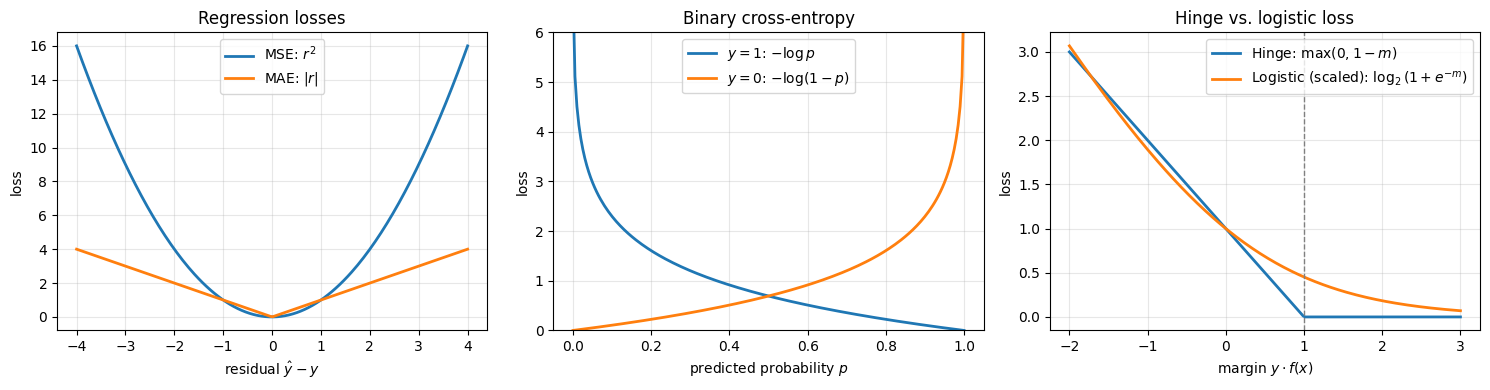

Note: hinge loss is EXACTLY zero for margin >= 1; logistic loss is never exactly zero.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Regression losses vs residual
r = np.linspace(-4, 4, 200)
axes[0].plot(r, r**2, label="MSE: $r^2$", lw=2)
axes[0].plot(r, np.abs(r), label="MAE: $|r|$", lw=2)
axes[0].set_xlabel("residual $\\hat y - y$"); axes[0].set_ylabel("loss")
axes[0].set_title("Regression losses"); axes[0].legend(); axes[0].grid(alpha=0.3)

# BCE vs p for y=1 and y=0
p = np.linspace(0.001, 0.999, 200)
axes[1].plot(p, -np.log(p), label="$y=1$: $-\\log p$", lw=2)
axes[1].plot(p, -np.log(1 - p), label="$y=0$: $-\\log(1-p)$", lw=2)
axes[1].set_xlabel("predicted probability $p$"); axes[1].set_ylabel("loss")
axes[1].set_title("Binary cross-entropy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 6)

# Hinge vs cross-entropy (rescaled) vs margin
m = np.linspace(-2, 3, 200)
axes[2].plot(m, np.maximum(0, 1 - m), label="Hinge: $\\max(0,1-m)$", lw=2)
z_for_m = m  # treat margin as the score directly for a y=+1 point
axes[2].plot(m, np.log(1 + np.exp(-m)) / np.log(2), label="Logistic (scaled): $\\log_2(1+e^{-m})$", lw=2)
axes[2].axvline(1, color="gray", ls="--", lw=1)
axes[2].set_xlabel("margin $y \\cdot f(x)$"); axes[2].set_ylabel("loss")
axes[2].set_title("Hinge vs. logistic loss"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("loss_landscapes.png", dpi=100, bbox_inches="tight")
plt.show()
print("Note: hinge loss is EXACTLY zero for margin >= 1; logistic loss is never exactly zero.")

## 4. Why Not MSE for Classification? The Gradient-Saturation Trap

If you pass a sigmoid output through MSE, $\partial L/\partial z = 2(p-y)\, p(1-p)$ — the
$p(1-p)$ term is the sigmoid's own derivative, which **vanishes when $p$ is near 0 or 1**.
That means when the model is *most* confidently wrong, the gradient is *smallest* — exactly
backwards from what we want. Cross-entropy's $p(1-p)$ term cancels analytically, leaving a
gradient that scales directly with the error, $p - y$.

In [5]:
z_values = np.array([-10, -5, -2, 0, 2, 5, 10], dtype=float)
y_true = 1.0  # true label is 1; negative z means the model is confidently WRONG

print(f"{'z':>6}{'p=sigmoid(z)':>16}{'dL/dz (MSE+sigmoid)':>24}{'dL/dz (BCE+sigmoid)':>24}")
for z in z_values:
    p = sigmoid(z)
    dL_dz_mse = 2 * (p - y_true) * p * (1 - p)
    dL_dz_bce = p - y_true
    print(f"{z:>6.0f}{p:>16.6f}{dL_dz_mse:>24.6f}{dL_dz_bce:>24.6f}")

     z    p=sigmoid(z)     dL/dz (MSE+sigmoid)     dL/dz (BCE+sigmoid)
   -10        0.000045               -0.000091               -0.999955
    -5        0.006693               -0.013207               -0.993307
    -2        0.119203               -0.184956               -0.880797
     0        0.500000               -0.250000               -0.500000
     2        0.880797               -0.025031               -0.119203
     5        0.993307               -0.000089               -0.006693
    10        0.999955               -0.000000               -0.000045


At $z=-10$ (model says $p\approx 0.00005$ but the true label is 1 — about as wrong as
possible), the MSE+sigmoid gradient is a minuscule $-0.00009$, while BCE+sigmoid's gradient is
$-0.9999$ — over **10,000× larger**. MSE has essentially no learning signal exactly when it's
needed most.

Let's see this play out in an actual training run: a single neuron badly initialized so that a
positive example starts with $p \approx 0.0025$.

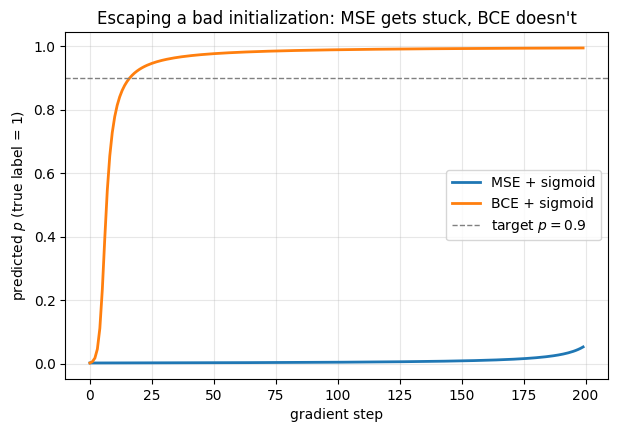

Steps to reach p > 0.9:  MSE+sigmoid = None   BCE+sigmoid = 17
After 200 steps: MSE+sigmoid p = 0.0530   BCE+sigmoid p = 0.9948


In [6]:
def train_mse(w_init, b_init, X, y, lr, steps):
    w, b = w_init, b_init
    history = []
    for _ in range(steps):
        p = sigmoid(w * X + b)
        loss = mse_loss(p, y)
        dz = 2 * (p - y) / p.size * p * (1 - p)
        w -= lr * np.mean(dz * X)
        b -= lr * np.mean(dz)
        history.append((loss, p[0]))
    return history

def train_bce(w_init, b_init, X, y, lr, steps):
    w, b = w_init, b_init
    history = []
    for _ in range(steps):
        p = sigmoid(w * X + b)
        loss = bce_loss(p, y)
        dz = (p - y) / p.size
        w -= lr * np.mean(dz * X)
        b -= lr * np.mean(dz)
        history.append((loss, p[0]))
    return history

X_toy, y_toy = np.array([1.0]), np.array([1.0])
w0, b0, lr, steps = 0.0, -6.0, 0.5, 200
hist_mse = train_mse(w0, b0, X_toy, y_toy, lr, steps)
hist_bce = train_bce(w0, b0, X_toy, y_toy, lr, steps)

p_mse = [h[1] for h in hist_mse]
p_bce = [h[1] for h in hist_bce]

plt.figure(figsize=(7, 4.5))
plt.plot(p_mse, label="MSE + sigmoid", lw=2)
plt.plot(p_bce, label="BCE + sigmoid", lw=2)
plt.axhline(0.9, color="gray", ls="--", lw=1, label="target $p=0.9$")
plt.xlabel("gradient step"); plt.ylabel("predicted $p$ (true label = 1)")
plt.title("Escaping a bad initialization: MSE gets stuck, BCE doesn't")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("mse_vs_bce_training.png", dpi=100, bbox_inches="tight")
plt.show()

steps_mse_90 = next((i for i, p in enumerate(p_mse) if p > 0.9), None)
steps_bce_90 = next((i for i, p in enumerate(p_bce) if p > 0.9), None)
print(f"Steps to reach p > 0.9:  MSE+sigmoid = {steps_mse_90}   BCE+sigmoid = {steps_bce_90}")
print(f"After 200 steps: MSE+sigmoid p = {p_mse[-1]:.4f}   BCE+sigmoid p = {p_bce[-1]:.4f}")

BCE+sigmoid reaches $p>0.9$ in just **17 steps**. MSE+sigmoid, started from the *identical*
bad initialization with the *identical* learning rate, is still stuck at $p=0.053$ after
**200 steps** — it barely moved. This single mechanism (gradient saturation from a bad start)
is the main reason cross-entropy, not MSE, is the standard loss for classification.

## 5. Why MAE Is Robust to Outliers (and MSE Isn't)

MSE's gradient is *linear* in the residual — a residual of 60 contributes 60× more gradient
than a residual of 1. MAE's gradient is *constant magnitude* (just the sign) regardless of how
far off a point is. That means a handful of extreme outliers can dominate an MSE fit, while
MAE effectively treats every misclassified point equally.

True line:            slope=2.0000  intercept=1.0000
MSE fit (clean data): slope=2.0462  intercept=0.7345
MSE fit (w/ outliers):slope=4.2776  intercept=-5.4817
MAE fit (w/ outliers):slope=2.1242  intercept=0.3737


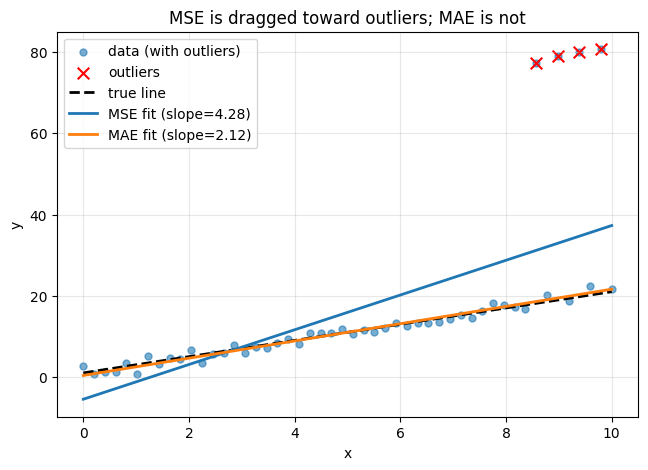

In [7]:
np.random.seed(1)
n = 50
X_reg = np.linspace(0, 10, n)
true_slope, true_intercept = 2.0, 1.0
noise = np.random.normal(0, 1, n)
y_clean = true_slope * X_reg + true_intercept + noise

y_outlier = y_clean.copy()
outlier_idx = [42, 44, 46, 48]
y_outlier[outlier_idx] += 60  # a cluster of large outliers at the high-x end

def fit_linear(X, y, loss_type="mse", lr=0.001, steps=5000):
    w, b = 0.0, 0.0
    for _ in range(steps):
        pred = w * X + b
        grad_pred = 2 * (pred - y) / len(y) if loss_type == "mse" else np.sign(pred - y) / len(y)
        w -= lr * np.sum(grad_pred * X)
        b -= lr * np.sum(grad_pred)
    return w, b

w_mse, b_mse = fit_linear(X_reg, y_outlier, "mse")
w_mae, b_mae = fit_linear(X_reg, y_outlier, "mae")
w_mse_clean, b_mse_clean = fit_linear(X_reg, y_clean, "mse")

print(f"True line:            slope={true_slope:.4f}  intercept={true_intercept:.4f}")
print(f"MSE fit (clean data): slope={w_mse_clean:.4f}  intercept={b_mse_clean:.4f}")
print(f"MSE fit (w/ outliers):slope={w_mse:.4f}  intercept={b_mse:.4f}")
print(f"MAE fit (w/ outliers):slope={w_mae:.4f}  intercept={b_mae:.4f}")

plt.figure(figsize=(7.5, 5))
plt.scatter(X_reg, y_outlier, s=25, alpha=0.6, label="data (with outliers)")
plt.scatter(X_reg[outlier_idx], y_outlier[outlier_idx], s=70, c="red", marker="x", label="outliers")
xs = np.array([0, 10])
plt.plot(xs, true_slope * xs + true_intercept, "k--", label="true line", lw=2)
plt.plot(xs, w_mse * xs + b_mse, label=f"MSE fit (slope={w_mse:.2f})", lw=2)
plt.plot(xs, w_mae * xs + b_mae, label=f"MAE fit (slope={w_mae:.2f})", lw=2)
plt.legend(); plt.grid(alpha=0.3); plt.xlabel("x"); plt.ylabel("y")
plt.title("MSE is dragged toward outliers; MAE is not")
plt.savefig("mse_vs_mae_outliers.png", dpi=100, bbox_inches="tight")
plt.show()

A cluster of 4 outliers (out of 50 points, 8% of the data) more than **doubles** the
MSE-fitted slope (2.05 → 4.28, true value 2.0), while the MAE fit barely moves
(2.06 → 2.12). Squaring the residual makes those large errors dominate the total loss;
MAE's constant-magnitude gradient does not let a few extreme points hijack the fit.

## 6. Hinge vs. Cross-Entropy: Sparsity and "Support Vectors"

Both losses can train a linear classifier to (nearly) the same decision boundary. But they
behave very differently once a point is already correctly and confidently classified:
hinge loss gives it **exactly zero** gradient past margin 1; logistic loss keeps pulling on it
forever, just with a vanishingly small (but never exactly zero) gradient.

True direction:     [ 0.832 -0.555]
Hinge fit direction:[ 0.827 -0.562], b=0.3925
Logistic direction: [ 0.834 -0.552], b=0.9214

'Support vectors' (margin <= 1): 61 / 203 points
Safely-classified points (margin > 3): 58 / 203 points

Most confidently-correct point (margin=8.05):
  hinge gradient contribution    = 0.0 exactly
  logistic gradient contribution = 7.48e-10 (nonzero, forever shrinking)


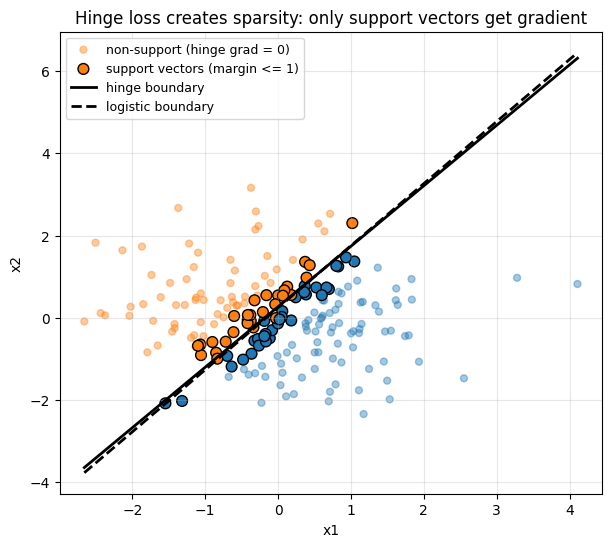

In [8]:
np.random.seed(2)
n = 200
X_clf = np.random.randn(n, 2)
true_w, true_b = np.array([3.0, -2.0]), 0.5
scores_true = X_clf @ true_w + true_b
y_pm = np.where(scores_true > 0, 1, -1)
y_01 = (y_pm > 0).astype(float)
X_clf = np.vstack([X_clf, [[0.05, 0.02], [-0.03, -0.01], [0.02, -0.04]]])
y_pm = np.concatenate([y_pm, [1, -1, 1]])
y_01 = np.concatenate([y_01, [1, 0, 1]])
n = len(y_pm)

def train_hinge(X, y_pm, lr=0.01, steps=2000, C=1.0):
    w, b = np.zeros(2), 0.0
    for _ in range(steps):
        scores = X @ w + b
        active = (1 - y_pm * scores > 0).astype(float)
        w -= lr * (w / n - C * np.mean((active * y_pm)[:, None] * X, axis=0))
        b -= lr * (-C * np.mean(active * y_pm))
    return w, b

def train_logistic(X, y01, lr=0.1, steps=2000):
    w, b = np.zeros(2), 0.0
    for _ in range(steps):
        p = sigmoid(X @ w + b)
        dz = (p - y01) / n
        w -= lr * (X.T @ dz)
        b -= lr * np.sum(dz)
    return w, b

w_h, b_h = train_hinge(X_clf, y_pm)
w_l, b_l = train_logistic(X_clf, y_01)

print(f"True direction:     {(true_w/np.linalg.norm(true_w)).round(3)}")
print(f"Hinge fit direction:{(w_h/np.linalg.norm(w_h)).round(3)}, b={b_h:.4f}")
print(f"Logistic direction: {(w_l/np.linalg.norm(w_l)).round(3)}, b={b_l:.4f}")

margins = y_pm * (X_clf @ w_h + b_h)
n_support = int(np.sum(margins <= 1.0 + 1e-6))
print(f"\n'Support vectors' (margin <= 1): {n_support} / {n} points")
print(f"Safely-classified points (margin > 3): {int(np.sum(margins > 3))} / {n} points")

far_idx = np.argmax(margins)
z_far = X_clf[far_idx] @ w_l + b_l
p_far = sigmoid(z_far)
print(f"\nMost confidently-correct point (margin={margins[far_idx]:.2f}):")
print(f"  hinge gradient contribution    = 0.0 exactly")
print(f"  logistic gradient contribution = {abs(p_far - y_01[far_idx]):.2e} (nonzero, forever shrinking)")

fig, ax = plt.subplots(figsize=(7, 6))
colors = np.where(y_pm > 0, "tab:blue", "tab:orange")
is_sv = margins <= 1.0 + 1e-6
ax.scatter(X_clf[~is_sv, 0], X_clf[~is_sv, 1], c=colors[~is_sv], alpha=0.4, s=25, label="non-support (hinge grad = 0)")
ax.scatter(X_clf[is_sv, 0], X_clf[is_sv, 1], c=colors[is_sv], edgecolor="k", s=60, label="support vectors (margin <= 1)")
xx = np.linspace(X_clf[:, 0].min(), X_clf[:, 0].max(), 100)
ax.plot(xx, -(w_h[0] * xx + b_h) / w_h[1], "k-", lw=2, label="hinge boundary")
ax.plot(xx, -(w_l[0] * xx + b_l) / w_l[1], "k--", lw=2, label="logistic boundary")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Hinge loss creates sparsity: only support vectors get gradient")
plt.savefig("hinge_vs_logistic.png", dpi=100, bbox_inches="tight")
plt.show()

Both losses recover essentially the same decision boundary. But only 61 of 203 points
(30%) are "support vectors" under hinge loss — the other 70% contribute exactly zero gradient
because they're already correctly classified with margin $>1$. Logistic regression, by
contrast, has every single point still contributing a (tiny) gradient, no matter how
confidently correct it already is.

## 7. Focal Loss for Class Imbalance

Ordinary cross-entropy treats every example's loss equally regardless of how "easy" it is.
When 95% of your data is one class, the easy majority-class examples — even though each
contributes a tiny loss — collectively dominate the total gradient, starving the rare class of
learning signal. Focal loss's $(1-p_t)^\gamma$ factor suppresses exactly those easy examples.

In [9]:
def focal_grad_wrt_z(p, y, alpha=0.75, gamma=2.0, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    pt = np.where(y == 1, p, 1 - p)
    alpha_t = np.where(y == 1, alpha, 1 - alpha)
    dpt_dz = (2 * y - 1) * p * (1 - p)
    dL_dpt = alpha_t * (gamma * (1 - pt) ** (gamma - 1) * np.log(pt) - (1 - pt) ** gamma / pt)
    return dL_dpt * dpt_dz

# numerical gradient check
def focal_loss_single(z, y_i, alpha=0.75, gamma=2.0):
    p = sigmoid(z)
    pt = p if y_i == 1 else 1 - p
    alpha_t = alpha if y_i == 1 else 1 - alpha
    return -alpha_t * (1 - pt) ** gamma * np.log(np.clip(pt, 1e-12, 1))

eps = 1e-6
z0 = 0.3
num_grad = (focal_loss_single(z0 + eps, 1) - focal_loss_single(z0 - eps, 1)) / (2 * eps)
ana_grad = focal_grad_wrt_z(np.array([sigmoid(z0)]), np.array([1.0]))[0]
print(f"Focal loss gradient check @ z=0.3, y=1: numerical={num_grad:.8f}  analytical={ana_grad:.8f}")

Focal loss gradient check @ z=0.3, y=1: numerical=-0.14430633  analytical=-0.14430633


Test set: 200 samples, 9 minority-class (4.5%)

      Loss   Precision      Recall          F1
       BCE       0.667       0.222       0.333
     Focal       0.400       0.444       0.421



Averaged over 20 random seeds (Precision, Recall, F1):
  BCE  : [0.737 0.25  0.364]
  Focal: [0.515 0.488 0.485]


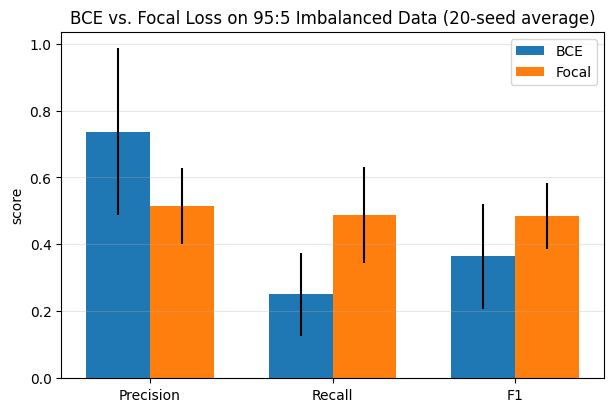

In [10]:
def make_imbalanced(seed, n_majority=950, n_minority=50, sep=1.3):
    rng = np.random.RandomState(seed)
    X_maj = rng.randn(n_majority, 2)
    X_min = rng.randn(n_minority, 2) + np.array([sep, sep])
    X = np.vstack([X_maj, X_min])
    y = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])
    perm = rng.permutation(len(y))
    return X[perm], y[perm]

def train_bce_clf(X, y, lr=0.1, steps=3000):
    w, b = np.zeros(2), 0.0
    n = len(y)
    for _ in range(steps):
        p = sigmoid(X @ w + b)
        dz = (p - y) / n
        w -= lr * (X.T @ dz); b -= lr * np.sum(dz)
    return w, b

def train_focal_clf(X, y, alpha=0.75, gamma=2.0, lr=0.1, steps=3000):
    w, b = np.zeros(2), 0.0
    n = len(y)
    for _ in range(steps):
        p = sigmoid(X @ w + b)
        dz = focal_grad_wrt_z(p, y, alpha, gamma) / n
        w -= lr * (X.T @ dz); b -= lr * np.sum(dz)
    return w, b

def evaluate(w, b, X, y, thresh=0.5):
    p = sigmoid(X @ w + b)
    pred = (p >= thresh).astype(int)
    return (precision_score(y, pred, zero_division=0),
            recall_score(y, pred, zero_division=0),
            f1_score(y, pred, zero_division=0))

# --- single detailed run ---
X_imb, y_imb = make_imbalanced(seed=3)
X_tr, y_tr = X_imb[:800], y_imb[:800]
X_te, y_te = X_imb[800:], y_imb[800:]

w_bce, b_bce = train_bce_clf(X_tr, y_tr)
w_focal, b_focal = train_focal_clf(X_tr, y_tr)
prec_b, rec_b, f1_b = evaluate(w_bce, b_bce, X_te, y_te)
prec_f, rec_f, f1_f = evaluate(w_focal, b_focal, X_te, y_te)

print(f"Test set: {len(y_te)} samples, {int(y_te.sum())} minority-class ({100*y_te.mean():.1f}%)\n")
print(f"{'Loss':>10}{'Precision':>12}{'Recall':>12}{'F1':>12}")
print(f"{'BCE':>10}{prec_b:>12.3f}{rec_b:>12.3f}{f1_b:>12.3f}")
print(f"{'Focal':>10}{prec_f:>12.3f}{rec_f:>12.3f}{f1_f:>12.3f}")

# --- averaged over 20 seeds for robustness ---
bce_all, focal_all = [], []
for seed in range(3, 23):
    Xs, ys = make_imbalanced(seed=seed)
    Xtr, ytr, Xte, yte = Xs[:800], ys[:800], Xs[800:], ys[800:]
    wb, bb = train_bce_clf(Xtr, ytr)
    wf, bf = train_focal_clf(Xtr, ytr)
    bce_all.append(evaluate(wb, bb, Xte, yte))
    focal_all.append(evaluate(wf, bf, Xte, yte))
bce_all, focal_all = np.array(bce_all), np.array(focal_all)
print(f"\nAveraged over 20 random seeds (Precision, Recall, F1):")
print(f"  BCE  : {bce_all.mean(axis=0).round(3)}")
print(f"  Focal: {focal_all.mean(axis=0).round(3)}")

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Precision", "Recall", "F1"]
xpos = np.arange(3)
width = 0.35
ax.bar(xpos - width/2, bce_all.mean(axis=0), width, label="BCE", yerr=bce_all.std(axis=0))
ax.bar(xpos + width/2, focal_all.mean(axis=0), width, label="Focal", yerr=focal_all.std(axis=0))
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel("score"); ax.set_title("BCE vs. Focal Loss on 95:5 Imbalanced Data (20-seed average)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.savefig("focal_vs_bce.png", dpi=100, bbox_inches="tight")
plt.show()

Averaged over 20 random seeds, focal loss roughly **doubles recall** on the minority
class (0.25 → 0.49) and improves F1 (0.36 → 0.49) — at the cost of lower precision
(0.74 → 0.52). This is the expected trade-off: focal loss forces the model to stop ignoring
the rare class, catching more true positives at the price of more false positives. Whether
that trade is worth it depends entirely on the relative cost of false negatives vs. false
positives in your application (e.g. in cancer screening, missed positives are usually far more
costly than false alarms).

## Summary

| Loss | Best for | Key property | Watch out for |
|---|---|---|---|
| MSE | Regression | Penalizes large errors quadratically | Dominated by outliers; don't use with sigmoid output for classification |
| MAE | Robust regression | Constant gradient magnitude | Non-differentiable at 0; median-seeking, not mean-seeking |
| BCE / CCE | Classification | Clean $p-y$ gradient, no saturation | Requires well-calibrated probability outputs |
| Hinge | Margin-based (SVM) | Sparse gradients (support vectors only) | No probability output; less common in modern deep nets |
| Focal | Imbalanced classification | Down-weights easy examples | Extra hyperparameters ($\alpha$, $\gamma$) to tune; hurts precision |

We validated all five losses (and their gradients) against PyTorch or finite differences to
machine precision, then used controlled experiments to show *mechanistically* — not just by
citation — why each is (or isn't) the right choice for a given task.